# Proof of concept: DoseEngine

Este notebook tem como propósito a exposição das ideias que serão aplicadas neste projeto, de forma mais direta, mais explicativa e com arquitetura mais simples.

É fruto da compilação de vários protótipos prévios que guiaram as decisões tomadas na construção modular do programa.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

## Cálculo de dose

Em radioterapia externa são aplicadas doses de radiação que permitem destruir células cancerígenas.
A quantidade de radiação usada deve ser escolhida com precisão de modo a resolver um problema de otimização: "Como eliminar eficazmente o tumor, mitigando ao máximo o dano em órgãos circundantes".

No âmbito deste projeto vamos focar-nos em radioterapia externa que usa fotões, ou seja, uma fonte externa emite raios X na direção do tumor alvo do paciente.
Algoritmos de cálculo de dose, neste contexto, pretendem modelar a deposição da energia induzida pela radiação ionizante. Isto inclui modelar os fenómenos de interação fotão-matéria tais como efeito de Compton e efeito fotoelétrico, dependendo de fatores como a energia dos fotões e a densidade do meio com que interagem.

Ao longo dos anos, algoritmos que calculam estas doses, de modo a equilibrar o índice terapéutico, têm evoluído em termos de precisão.
Outro fator a ter em conta é o tempo e poder computacional usados para obter os resultados. Usando algoritmos de Monte Carlo é possível obter elevada precisão, simulando a natureza estocástica dos fenómenos de interação radiação-matéria, mas o tempo de computação tende a ser longo, havendo algoritmos mais rápidos sacrificando alguma precisão.

Neste projeto vamos focar-nos em algoritmos mais simples, que permitem obter os resultados em alguns segundos, explorando os fenómenos físicos associados e comparando os resultados das diferentes abordagens.

## Fantomas

Em ambiente clínico são usadas imagens de TAC (tomografia axial computorizada) dos pacientes para derivar o seu perfil de densidade eletrónica na zona circundante ao tumor. Esse processo vai ser desenvolvido neste projeto mas para introduzir a ideia vamos gerar fantomas.

O fantoma faz isto artificialmente, será, neste caso, uma matriz de numpy que caracteriza a densidade eletrónica do espaço. Dependendo do tecido presente a densidade é maior ou menor. Vamos assumir que o meio em geral é constituído por água (fantoma de água), já que os tecidos moles em geral possuem um comportamento radiológico semelhante sendo atribuída uma densidade eletrónica relativa de valor $\rho_e^{rel} = 1$.

Vamos criar um domínio 2D (uma secção transversal) de 20x40 cm. O caso de estudo será a interface tecido-pulmão. O pulmão, sendo preenchido por ar, tem uma densidade muito inferior à da água, o que altera drasticamente o transporte de radiação primária e o espalhamento de eletrões secundários.

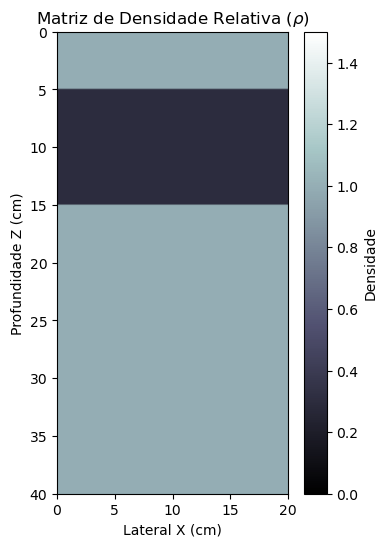

In [12]:
# Discretizar o domínio
dx, dz = 0.2, 0.2 # a nossa unidade na grelha será de 0.2 cm
nx, nz = 100, 200 # número de pixels nas duas direções

# Criar o fantoma de água
phantom = np.ones((nz, nx)) # neste momento o fantoma é homogéneo, a ordem é muito importante

# Inserir o órgão, neste caso um pulmão, no intervalo z = [5, 15] cm
z_i = int(5.0 / dz) # dividindo pela unidade de discretização podemos usar o valor em cm
z_f = int(15.0 / dz)
phantom[z_i: z_f, :] = 0.3

# Visualização do fantoma
plt.figure(figsize=(4,6))
plt.imshow(phantom, cmap='bone', extent=[0, nx*dx, nz*dz, 0], vmin=0, vmax=1.5)
plt.title("Matriz de Densidade Relativa ($\\rho$)")
plt.colorbar(label="Densidade")
plt.ylabel("Profundidade Z (cm)")
plt.xlabel("Lateral X (cm)")
plt.show()

